# Create WecOptTool Model for the Marson WEC concept

In [1]:
import numpy as np
import jax.numpy as jnp
import capytaine as cpt
from capytaine.io.meshio import load_from_meshio
import matplotlib.pyplot as plt
from scipy.optimize import brute
import pygmsh
import gmsh
from scipy.linalg import block_diag
import xarray as xr
import jax
import os

import wecopttool as wot

## set colorblind-friendly colormap for plots
plt.style.use('tableau-colorblind10')

import logging
logging.getLogger().setLevel(logging.INFO)

### Waves and Frequency array

In [2]:
wavefreq = 1/8 # Hz
f1 = wavefreq
nfreq = 10

freq = wot.frequency(f1, nfreq, False) # False -> no zero frequency

amplitude = 0.01/2 # m
phase = 30 # degrees
wavedir = 0 # degrees

waves = wot.waves.regular_wave(f1, nfreq, wavefreq, amplitude, phase, wavedir)

#### WEC geometry mesh
Now we will create a surface mesh for the WEC hull and store it using the `FloatingBody` object from Capytaine.

INFO:capytaine.io.meshio:Stored 3980 triangle faces as quadrilaterals
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio_0"), lid_mesh=None, dofs={}, center_of_mass=[ 0.    0.   -0.54], name="platform").
INFO:capytaine.bodies.bodies:Clipping platform with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="platform").rotation_center = [ 0.    0.   -0.54]
INFO:capytaine.io.meshio:Stored 312 triangle faces as quadrilaterals
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio_6"), lid_mesh=None, dofs={}, center_of_mass=[-0.72  0.   -0.36], name="flap1").
INFO:capytaine.bodies.bodies:Clipping flap1 with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.meshes.clipper:Clipping mesh_from_meshio_6 by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.
INFO:capyta

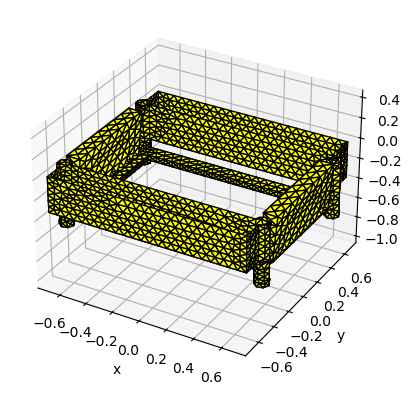

In [3]:
# platform is a rectangle with cg at -0.46 and 1.44 m long, 0.76 m wide
flapThicknessBottom = 0.04
flapThicknessTop = 0.1

platformLength = 1.44 
outboardWidth = 0.1
platformWidth = 0.76+2*outboardWidth
platformHeight = 0.05
platformCenter = [0, 0, -0.46]
columnsRadius = 0.05
columnsDraft = 0.6
columnsXY = [platformLength/2, platformWidth/2]
cutoutWidth = 0.76
cutoutLength = 1.44-2*outboardWidth

# floats attached to side of platform
floatWidth = 0.2
floatHeight = 0.35

flapWidth = platformWidth-2*outboardWidth
flapHeight = 0.45
flap1CG = [-platformLength/2, 0, -0.36] # from water surface/origin
flap2CG = [platformLength/2, 0, -0.36] # from water surface/origin

with pygmsh.occ.Geometry() as geom:
    gmsh.option.setNumber('Mesh.MeshSizeFactor', 0.3)
    platform = geom.add_box([-platformLength/2, -platformWidth/2, platformCenter[2] - platformHeight/2], [platformLength,platformWidth,platformHeight])
    cutout = geom.add_box([-cutoutLength/2, -cutoutWidth/2, platformCenter[2] - platformHeight/2], [cutoutLength,cutoutWidth,platformHeight])
    cyl1 = geom.add_cylinder([-columnsXY[0], -columnsXY[1], -columnsDraft],[0, 0, columnsDraft+.01], columnsRadius)
    cyl2 = geom.add_cylinder([-columnsXY[0], columnsXY[1], -columnsDraft],[0, 0, columnsDraft+.01], columnsRadius)
    cyl3 = geom.add_cylinder([columnsXY[0], -columnsXY[1], -columnsDraft],[0, 0, columnsDraft+.01], columnsRadius)
    cyl4 = geom.add_cylinder([columnsXY[0], columnsXY[1], -columnsDraft],[0, 0, columnsDraft+.01], columnsRadius)
    float1 = geom.add_box([-platformLength/2, -platformWidth/2-0.2, -floatHeight], [platformLength,floatWidth,floatHeight])
    float2 = geom.add_box([-platformLength/2, platformWidth/2, -floatHeight], [platformLength,floatWidth,floatHeight])
    platformCutout = geom.boolean_difference(platform,cutout)
    geom.boolean_union([platformCutout,cyl1,cyl2,cyl3,cyl4,float1,float2])
    platformMesh = geom.generate_mesh()

with pygmsh.geo.Geometry() as geom:
    flap1 = geom.add_polygon(
            [[-platformLength/2 - flapThicknessBottom/2, -flapWidth/2, platformCenter[2]],
            [-platformLength/2 + flapThicknessBottom/2, -flapWidth/2, platformCenter[2]],
            [-platformLength/2 + flapThicknessTop/2, -flapWidth/2, -.01],
            [-platformLength/2 - flapThicknessTop/2, -flapWidth/2, -.01]],mesh_size=0.1)
    geom.extrude(flap1,[0,flapWidth,0])
    flap1Mesh = geom.generate_mesh()

with pygmsh.geo.Geometry() as geom:
    flap2 = geom.add_polygon(
            [[platformLength/2 - flapThicknessBottom/2, -flapWidth/2, platformCenter[2]],
            [platformLength/2 + flapThicknessBottom/2, -flapWidth/2, platformCenter[2]],
            [platformLength/2 + flapThicknessTop/2, -flapWidth/2, -.01],
            [platformLength/2 - flapThicknessTop/2, -flapWidth/2, -.01]],mesh_size=0.1)
    geom.extrude(flap2,[0,flapWidth,0])
    flap2Mesh = geom.generate_mesh()


# define the floating body
platform = cpt.FloatingBody(mesh=platformMesh, name=f'platform', center_of_mass=[0,0,-0.54])
platform = platform.immersed_part()
platform.rotation_center = platform.center_of_mass
platform.add_translation_dof(name='Surge')
platform.add_translation_dof(name='Heave')
platform.add_rotation_dof(name='Pitch')
platform.inertia_matrix = platform.compute_rigid_body_inertia()
rigid_inertia_matrix_xr = xr.DataArray(data=np.asarray((np.diag([350,350,30]))),
                            dims=['influenced_dof', 'radiating_dof'],
                            coords={'influenced_dof': list(platform.dofs),
                                    'radiating_dof': list(platform.dofs)},
                            name="inertia_matrix")

# Set FloatingBody inertia matrix
platform.inertia_matrix = rigid_inertia_matrix_xr
platform.hydrostatic_stiffness = platform.compute_hydrostatic_stiffness()

# define the floating body
flap1 = cpt.FloatingBody(mesh=flap1Mesh, name=f'flap1', center_of_mass=flap1CG)
flap1 = flap1.immersed_part()
flap1.rotation_center = flap1CG # define rotation about cg and M4E will handle transformaiton
flap1.add_translation_dof(name='Surge')
flap1.add_translation_dof(name='Heave')
flap1.add_rotation_dof(name='Pitch')
rigid_inertia_matrix_xr = xr.DataArray(data=np.asarray((np.diag([0.5*(.05*.76*.56)*1000,0.5*(.05*.76*.56)*1000,1.19]))),
                            dims=['influenced_dof', 'radiating_dof'],
                            coords={'influenced_dof': list(flap1.dofs),
                                    'radiating_dof': list(flap1.dofs)},
                            name="inertia_matrix")

# Set FloatingBody inertia matrix
flap1.inertia_matrix = rigid_inertia_matrix_xr
flap1.hydrostatic_stiffness = flap1.compute_hydrostatic_stiffness()

# define the floating body
flap2 = cpt.FloatingBody(mesh=flap2Mesh, name=f'flap2', center_of_mass=flap2CG)
flap2 = flap2.immersed_part()
flap2.rotation_center = flap2CG
flap2.add_translation_dof(name='Surge')
flap2.add_translation_dof(name='Heave')
flap2.add_rotation_dof(name='Pitch')
rigid_inertia_matrix_xr = xr.DataArray(data=np.asarray((np.diag([0.5*(.05*.76*.56)*1000,0.5*(.05*.76*.56)*1000,1.19]))),
                            dims=['influenced_dof', 'radiating_dof'],
                            coords={'influenced_dof': list(flap2.dofs),
                                    'radiating_dof': list(flap2.dofs)},
                            name="inertia_matrix")

# Set FloatingBody inertia matrix
flap2.inertia_matrix = rigid_inertia_matrix_xr
flap2.hydrostatic_stiffness = flap2.compute_hydrostatic_stiffness()

all_bodies = platform + flap1 + flap2

#all_bodies.show()
all_bodies.show_matplotlib()

In [4]:
fname = 'bem.nc'
if os.path.exists(fname):
    bem_data = wot.read_netcdf(fname)
else:
    bem_data = wot.run_bem(all_bodies, freq, wave_dirs=0)
    bem_data['radiating_dof'] = bem_data['radiating_dof'].astype(str)
    bem_data['influenced_dof'] = bem_data['influenced_dof'].astype(str)
    wot.write_netcdf(fname, bem_data)

In [5]:
#import multibody as mb
#import sympy
#import m4e_foswec

#MBDsys = mb.MBDSystem.from_example(m4e_foswec)

# Print the original rotation matrix
#print("Original Rotation Matrix (R):")
#print(np.array(MBDsys.R))

# Create a mapping of symbols to values based on their names
#value_mapping = {
#    'Theta_1': 0,
#    'Theta_2': 0,
#    'Theta_3': 0,
#}

#substitution_dict = {symbol: value_mapping[str(symbol)] for symbol in list(MBDsys.R.free_symbols) if str(symbol) in value_mapping}
#R_subs = MBDsys.R.subs(substitution_dict)
#print("Substituted Rotation Matrix (R_subs):")
#print(np.array(R_subs))


In [6]:
# Alvaro's code
import multibody as mb
from multibody import MbdSystem, linearize_mbd
import sympy as sym
import m4e_foswec
 
MBDsys = MbdSystem.from_example(m4e_foswec)
 
# Print the original rotation matrix
# print("Original Rotation Matrix (R):")
# sym.pprint(MBDsys.R)
 
# Create a mapping of symbols to values based on their names
value_mapping = {
    'Theta_1': 0,
    'Theta_2': 0,
    'Theta_3': 0,
}
 
# TODO: this should be using mainNumVars
substitution_dict = {symbol: value_mapping[str(symbol)] for symbol in list(MBDsys.R.free_symbols) if str(symbol) in value_mapping}
print(substitution_dict)
R_subs = MBDsys.R.subs(substitution_dict)
 
np.set_printoptions(precision=2, suppress=True, linewidth=200)
# print("Substituted Rotation Matrix (R_subs):")
# print(np.array(R_subs,dtype=float))
 
# Linearize the system about the equilibrium position
mainNumVars = MBDsys.ic
q0 = np.hstack((mainNumVars[:2], np.array([0, 0, 0])))  # The three zeroes come from value_mapping
 
# Obtain the mass and inertia values from all_bodies
mass_and_inertia = np.diag(all_bodies.inertia_matrix.values)
m0 = mass_and_inertia[::3]
J0 = mass_and_inertia[2::3]
 
# Linearize the mbd system
linMBD  = linearize_mbd(MBDsys, q0, m0, J0)
 
# Assuming no optimization
m = linMBD.Mbar(*mainNumVars)
c = linMBD.Cbar(*mainNumVars) # zero because no PTO
k = linMBD.Kbar(*mainNumVars) # zero because no PTO
 
# Variables for BEM data reduction
R0  = MBDsys.R_func(*mainNumVars)
RD0 = MBDsys.RD_func(*mainNumVars)
qd0         = [0] * len(MBDsys.QD) # zero velocities
subs_base   = dict(zip(MBDsys.Q, q0)) | dict(zip(MBDsys.QD, qd0))
dxdq0       = np.asarray(MBDsys.Pos.jacobian(MBDsys.Q).subs(subs_base),dtype=np.float64) # Can coincide with R0 but not always? To check

Table validation successful:	 No errors found.
Forces validation successful:	 No errors found.
Points validation successful:	 No errors found.


Bodies and joints table:
 Joint Connected Bodies Joint Type                          ParentCGtoJoint         JointtoChildCG Prismatic Direction
     1              0 1          F                  [0, -0.540000000000000]               NaN  NaN            NaN  NaN
     2              1 2          R [-0.720000000000000, 0.0400000000000000] [0, 0.140000000000000]            NaN  NaN
     3              1 3          R  [0.720000000000000, 0.0400000000000000] [0, 0.140000000000000]            NaN  NaN

Points table:
Empty DataFrame
Columns: [Body, PointType, PointID, Rel coordinates]
Index: []

Forces table:
Empty DataFrame
Columns: [ForceType, BodiesConnected, PointType, PointID, ForceComponents, SpringParameters, DamperParameters]
Index: []

The variables that require initial conditions, in this order, are:
[X_1, Z_1, Theta_1, Theta_2, Theta_3, XD

In [7]:
#mass_matrix = block_diag(platform.inertia_matrix.values,flap1.inertia_matrix.values,flap2.inertia_matrix.values)

#added_mass = np.squeeze(bem_data['added_mass'].data) # Added mass
#radiation_damping = np.squeeze(bem_data['radiation_damping'].data)  # Radiation damping
#hydrostatic_stiffness = np.squeeze(bem_data['hydrostatic_stiffness'].data)  # Hydrostatic stiffness
#excitation_force = np.squeeze(bem_data['excitation_force'].data) # Excitation force

#omega = freq*2*np.pi
#impedance_matrix = (mass_matrix + added_mass)*1j*omega[:, np.newaxis, np.newaxis] + radiation_damping - (1j/omega[:, np.newaxis, np.newaxis])*np.repeat(hydrostatic_stiffness[np.newaxis, :, :], 10, axis=0)
#impedance_reduced = np.array(R_subs,dtype=np.complex128).T @ impedance_matrix @ np.array(R_subs,dtype=np.complex128)

#hydrostatic_stiffness_reduced = (np.array(R_subs,dtype=np.complex128).T @ hydrostatic_stiffness @ np.array(R_subs,dtype=np.complex128))

#excitation_reduced = np.squeeze(bem_data['excitation_force'].values @ np.array(R_subs,dtype=np.complex128))[:,np.newaxis,:]

#wave_direction = np.array([wavedir,])
#nwave_direction = len(wave_direction)
#coords_exc = {
#    'omega': (['omega'], omega, {'units': 'rad/s'}),
#    'wave_direction': (['wave_direction'], wave_direction, {'units': 'rad'}),
#    'influenced_dof': (['influenced_dof'], ['surge_platform', 'heave_platform','pitch_platform','pitch_flap1','pitch_flap2'], {}),
#}
#excitation_reduced = xr.DataArray(excitation_reduced, coords=coords_exc, attrs={})

In [8]:
# Alvaro's code
added_mass = np.squeeze(bem_data['added_mass'].data) # Added mass
radiation_damping = np.squeeze(bem_data['radiation_damping'].data)  # Radiation damping
hydrostatic_stiffness = np.squeeze(bem_data['hydrostatic_stiffness'].data)  # Hydrostatic stiffness
excitation_force = np.squeeze(bem_data['excitation_force'].data) # Excitation force
 
# Hydrodynamics mapping to joint coordinates
added_mass_reduced = R0.T @ added_mass @ R0
rad_damp_reduced = R0.T @ radiation_damping @ R0 + R0.T @ all_bodies.inertia_matrix.values @ RD0
hydro_stiff_reduced = R0.T @ hydrostatic_stiffness @ dxdq0
 
# System assembly in reduced coordinates
Mtotal = m[None, :, :] + added_mass_reduced
Ctotal = c[None, :, :] + rad_damp_reduced
Ktotal = k + hydro_stiff_reduced
 
omega = freq*2*np.pi
impedance_reduced = Mtotal * (1j * omega[:, None, None]) + Ctotal - 1j * Ktotal[None, :, :] * (1/omega)[:, None, None]
# impedance_matrix = (mass_matrix + added_mass)*1j*omega[:, np.newaxis, np.newaxis] + radiation_damping - (1j/omega[:, np.newaxis, np.newaxis])*np.repeat(hydrostatic_stiffness[np.newaxis, :, :], 10, axis=0)
# impedance_reduced = np.array(R_subs,dtype=np.complex128).T @ impedance_matrix @ np.array(R_subs,dtype=np.complex128)
 
# impedance_reduced = Mtotal * (1j * omega)[:, None, None] + Ctotal - 1j * Ktotal[None, :, :] * (1/omega)[:, None, None]
hydrostatic_stiffness_reduced = hydro_stiff_reduced
 
print(impedance_reduced.shape)
 
excitation_reduced = np.squeeze(bem_data['excitation_force'].values @ np.array(R_subs,dtype=np.complex128))[:,np.newaxis,:]
 
wave_direction = np.array([wavedir,])
nwave_direction = len(wave_direction)
coords_exc = {
    'omega': (['omega'], omega, {'units': 'rad/s'}),
    'wave_direction': (['wave_direction'], wave_direction, {'units': 'rad'}),
    'influenced_dof': (['influenced_dof'], ['surge_platform', 'heave_platform','pitch_platform','pitch_flap1','pitch_flap2'], {}),
}
excitation_reduced = xr.DataArray(excitation_reduced, coords=coords_exc, attrs={})
 

(10, 5, 5)


In [ ]:
# add forces to stabilize system
mooring_stiffness = np.diag([3*1e5, 6e4, 5e4, 0, 0, 0, 0, 0, 0])
mooring_stiffness = R0.T @ mooring_stiffness @ dxdq0

mooring_damping = np.diag([3*1e4, 5e4, 5e5, 0, 0, 0, 0, 0, 0])
mooring_damping = R0.T @ mooring_damping @ R0

def f_mooring(wec, x_wec, x_opt, wave, nsubsteps=1):
    pos = wec.vec_to_dofmat(x_wec)
    vel = jnp.dot(wec.derivative_mat,pos)
 
    time_matrix = wec.time_mat_nsubsteps(nsubsteps)
    mooring = -pos @ mooring_stiffness - vel @ mooring_damping
    #print(np.shape(mooring))
    #print(mooring)
    mooring_force = jnp.dot(time_matrix,mooring)
    #print(mooring_force)
    return mooring_force

# WecOptTool does not take gravity into account and assumes equilibrium so no pretension needed

f_add = {'mooring': f_mooring}

In [13]:
wec = wot.WEC.from_impedance(
    freq,
    impedance=impedance_reduced,
    exc_coeff=excitation_reduced,
    hydrostatic_stiffness=hydrostatic_stiffness_reduced,
    constraints=None,
    f_add=f_add,
)

# Objective function
obj_fun = lambda wec, x_wec, x_opt, waves : 0
nstate_opt = 0

# Solve
scale_x_wec = 1e1
scale_x_opt = 1e-3
scale_obj = 1e-2

results = wec.solve(
    waves,
    obj_fun,
    nstate_opt,
    scale_x_wec=scale_x_wec,
    scale_x_opt=scale_x_opt,
    scale_obj=scale_obj,
)


[14:14:53] WARNING  Real part of impedance for 2 has negative or close to zero terms. Shifting up elements [4] to a
                    minimum of  1e-06 N/(m/s)

INFO:wecopttool.core:Solving pseudo-spectral control problem for realization number 0.


(20, 5)
(20, 5)


INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [5.66e-02, nan, 0.00e+00]
INFO:wecopttool.core:Optimization terminated successfully    (Exit mode 0)


Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.0
            Iterations: 1
            Function evaluations: 2
            Gradient evaluations: 1


(20, 5)


c:\Users\jtgrasb\AppData\Local\anaconda3\envs\wot_dev\Lib\site-packages\wecopttool\core.py:967: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'omega' ('omega',) The recommendation is to set join explicitly for this case.
  results_fd = xr.merge([fd_state, fd_forces, wave])
c:\Users\jtgrasb\AppData\Local\anaconda3\envs\wot_dev\Lib\site-packages\wecopttool\core.py:967: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  results_fd 

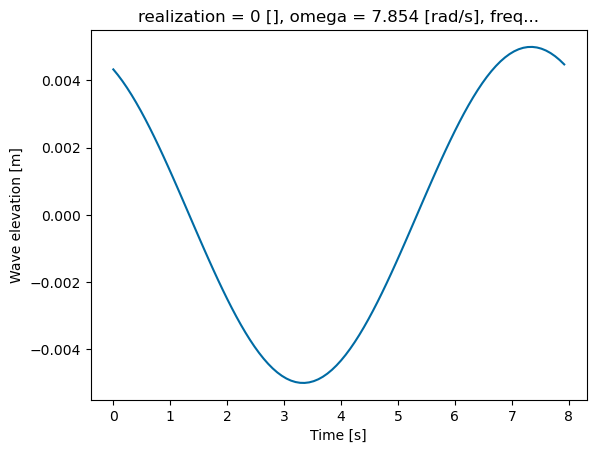

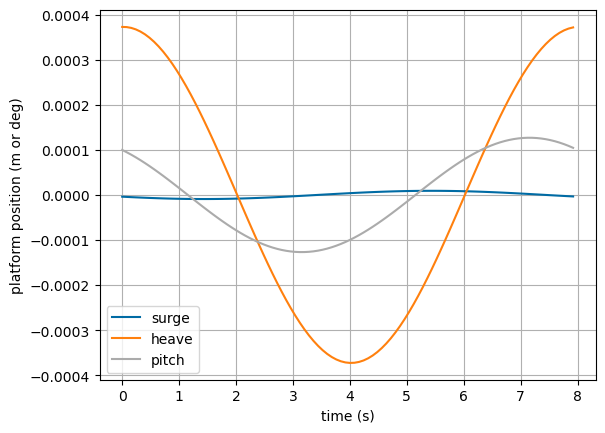

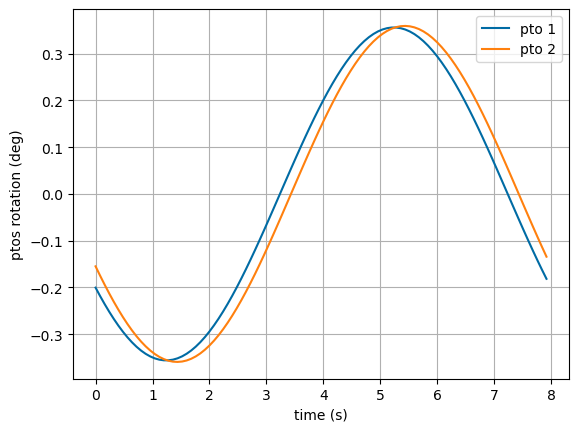

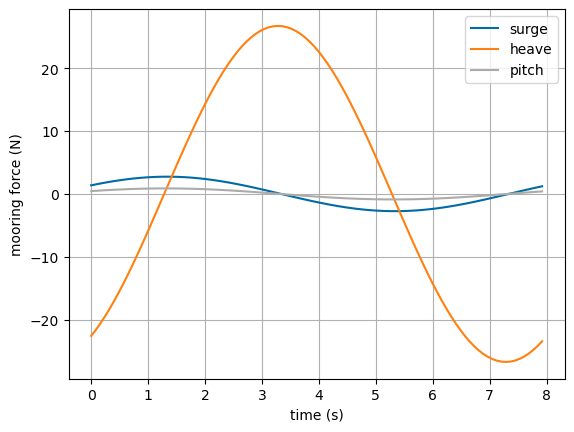

In [14]:
nsubsteps = 5
wec_fdom, wec_tdom = wec.post_process(wec, results, waves, nsubsteps=nsubsteps)

wec_tdom['wave_elev'].plot()

plt.figure()
plt.plot(wec_tdom['time'],wec_tdom.pos[0,0,:])
plt.plot(wec_tdom['time'],wec_tdom.pos[0,1,:])
plt.plot(wec_tdom['time'],wec_tdom.pos[0,2,:]*180/np.pi)
plt.xlabel('time (s)')
plt.ylabel('platform position (m or deg)')
plt.legend(['surge','heave','pitch'])
plt.grid()


plt.figure()
plt.plot(wec_tdom['time'],wec_tdom.pos[0,3,:]*180/np.pi)
plt.plot(wec_tdom['time'],wec_tdom.pos[0,4,:]*180/np.pi)
plt.xlabel('time (s)')
plt.ylabel('ptos rotation (deg)')
plt.legend(['pto 1', 'pto 2'])
plt.grid()

#print(wec_tdom['force'].sel(type='mooring').coords)

plt.figure()
plt.plot(wec_tdom['time'],np.squeeze(wec_tdom['force'].sel(type='mooring',influenced_dof='DOF_0')))
plt.plot(wec_tdom['time'],np.squeeze(wec_tdom['force'].sel(type='mooring',influenced_dof='DOF_1')))
plt.plot(wec_tdom['time'],np.squeeze(wec_tdom['force'].sel(type='mooring',influenced_dof='DOF_2')))
plt.xlabel('time (s)')
plt.ylabel('mooring force (N)')
plt.legend(['surge', 'heave','pitch'])
plt.grid()